In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
%matplotlib inline


In [6]:
day_df = pd.read_csv("C:/Users/harsh/Documents/infosys/Dataset exploration/day.csv")
hour_df = pd.read_csv("C:/Users/harsh/Documents/infosys/Dataset exploration/hour.csv")


In [7]:
def clean_dataset(df):
    # Create a copy to avoid modifying the original dataframe
    df = df.copy()
    
    # Columns that are not needed for prediction
    # 'casual' and 'registered' are already included in total count
    drop_cols = ["casual", "registered"]
    
    # Drop columns safely (no error if column does not exist)
    return df.drop(columns=drop_cols, errors="ignore")


FEATURE ENGINEERING 


In [14]:
def hour_feature_engineering(df):
    # Copy dataframe to keep original safe
    df = df.copy()
    
    # Mark weekends (Sunday=0, Saturday=6)
    df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)

        # Function to classify hour into part of the day
    def part_of_day(hr):
        if 5 <= hr <= 11:
            return "Morning"
        elif 12 <= hr <= 16:
            return "Afternoon"
        elif 17 <= hr <= 21:
            return "Evening"
        else:
            return "Night"

        # Apply part of day classification
    df["part_of_day"] = df["hr"].apply(part_of_day)

        # Mark peak commuting hours
    df["is_peak_hour"] = df["hr"].isin([7, 8, 9, 17, 18, 19]).astype(int)
        # Mark late-night hours
    df["is_night"] = df["hr"].isin([22, 23, 0, 1, 2, 3, 4]).astype(int)

        # Encode hour cyclic nature using sine and cosine
    df["hr_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
    df["hr_cos"] = np.cos(2 * np.pi * df["hr"] / 24)

        # Encode month cyclic nature
    df["mnth_sin"] = np.sin(2 * np.pi * (df["mnth"] - 1) / 12)
    df["mnth_cos"] = np.cos(2 * np.pi * (df["mnth"] - 1) / 12)

        # Encode weekday cyclic nature
    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

        # Heat index combines temperature and humidity
    df["heat_index"] = df["temp"] * df["hum"]

        # Wind chill approximation
    df["wind_chill"] = df["temp"] - df["windspeed"] * 0.7

        # Bad weather indicator
    df["bad_weather"] = df["weathersit"].isin([3, 4]).astype(int)

        # Overall weather severity score
    df["weather_severity"] = (
        df["weathersit"] * 0.4 +
        df["windspeed"] * 0.3 +
        df["hum"] * 0.3
    )

    return df



In [19]:
def day_feature_engineering(df, use_lags=True):
    # Copy dataframe
    df = df.copy()

        # Convert to datetime and sort by date
    df["dteday"] = pd.to_datetime(df["dteday"])
    df = df.sort_values("dteday")

        # Extract weekday from date
    df["weekday"] = df["dteday"].dt.weekday

        # Weekend flag
    df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)

    df["mnth_sin"] = np.sin(2 * np.pi * (df["mnth"] - 1) / 12)
    df["mnth_cos"] = np.cos(2 * np.pi * (df["mnth"] - 1) / 12)

    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

        # Quarter of the year
    df["quarter"] = ((df["mnth"] - 1) // 3 + 1)

        # Peak seasons (summer & fall)
    df["is_peak_season"] = df["season"].isin([2, 3]).astype(int)

        # Interaction of temperature and humidity
    df["temp_humidity"] = df["temp"] * df["hum"]
    
        # Interaction of temperature and windspeed
    df["temp_windspeed"] = df["temp"] * df["windspeed"]

        # Combined weather severity score
    df["weather_severity"] = (
        df["weathersit"] * 0.5 +
        df["windspeed"] * 0.3 +
        df["hum"] * 0.2
    )

        # Remove unused columns
    df.drop(columns=["instant", "dteday"], inplace=True, errors="ignore")

        # Remove rows with missing values
    df.dropna(inplace=True)

    return df



In [14]:
hour_results, trained_hour_models, X_train_hour, X_test_hour, y_train_hour, y_test_hour = train_and_evaluate_models(hour_df_final, "hour")



Training models for HOUR dataset
Random Forest trained
Gradient Boosting trained
XGBoost trained
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1378
[LightGBM] [Info] Number of data points in the train set: 13903, number of used features: 26
[LightGBM] [Info] Start training from score 174.639143
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
LightGBM trained


In [15]:
day_results, trained_day_models, X_train_day, X_test_day, y_train_day, y_test_day = train_and_evaluate_models(day_df_final, "day")



Training models for DAY dataset
Random Forest trained
Gradient Boosting trained
XGBoost trained
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1443
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 21
[LightGBM] [Info] Start training from score 4153.599315
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

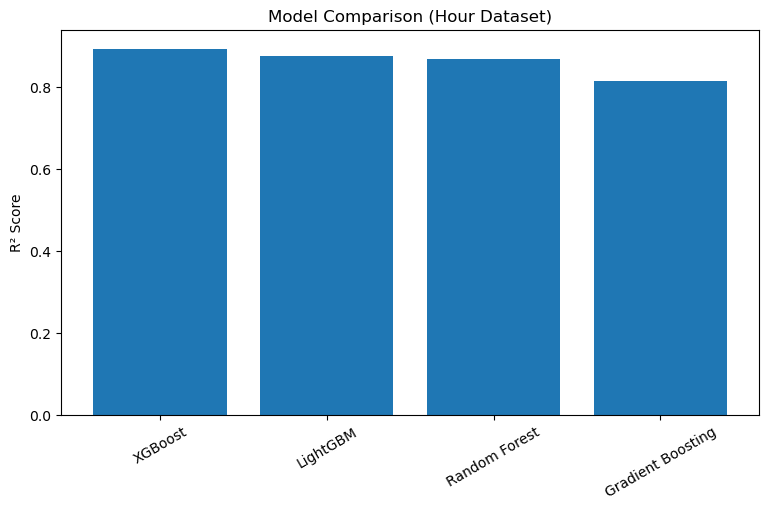

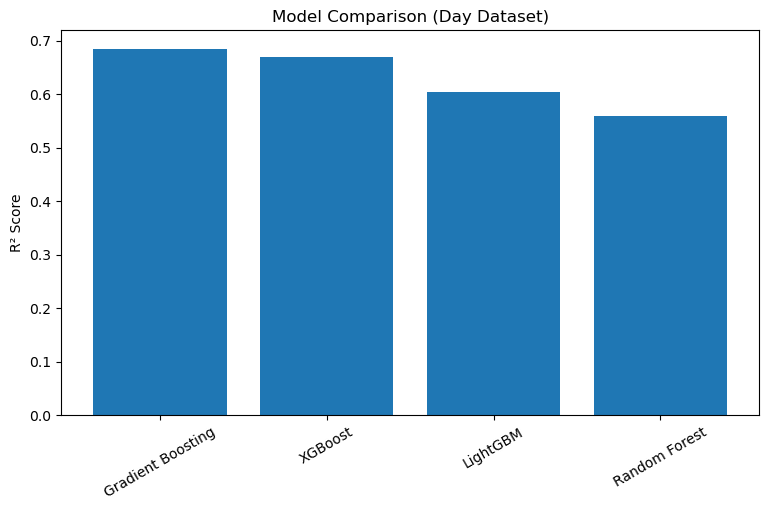

In [16]:
plt.figure(figsize=(9,5))
plt.bar(hour_results["Model"], hour_results["R2"])
plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("Model Comparison (Hour Dataset)")
plt.show()

plt.figure(figsize=(9,5))
plt.bar(day_results["Model"], day_results["R2"])
plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("Model Comparison (Day Dataset)")
plt.show()


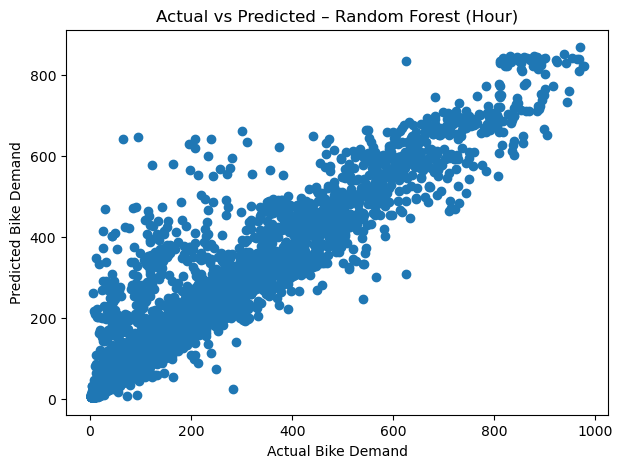

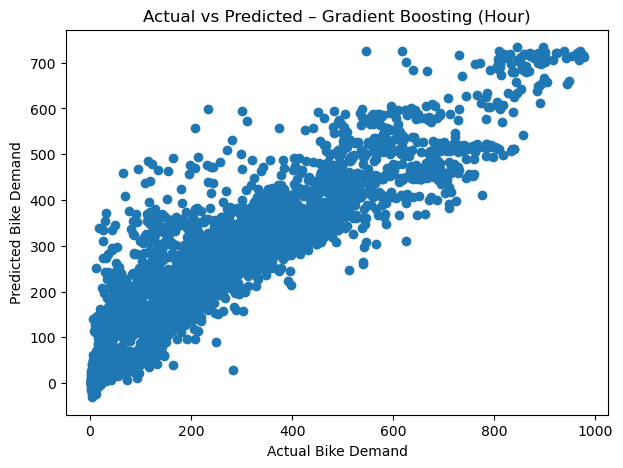

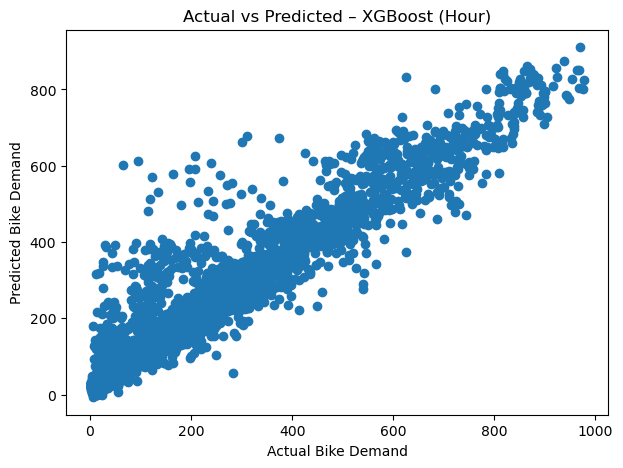

[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2


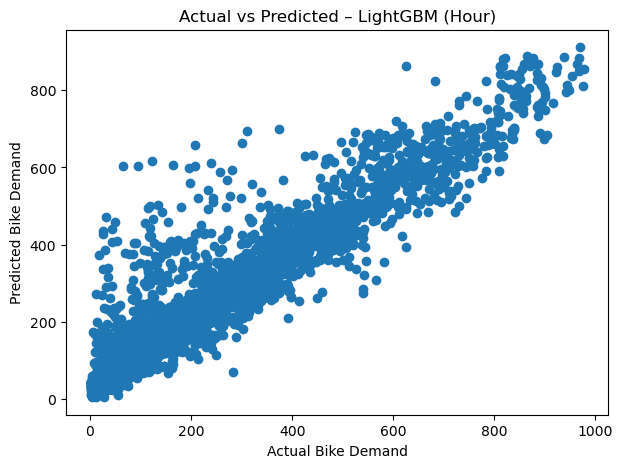

In [17]:
for name, model in trained_hour_models.items():
    y_pred = model.predict(X_test_hour)

    plt.figure(figsize=(7,5))
    plt.scatter(y_test_hour, y_pred)
    plt.xlabel("Actual Bike Demand")
    plt.ylabel("Predicted Bike Demand")
    plt.title(f"Actual vs Predicted – {name} (Hour)")
    plt.show()


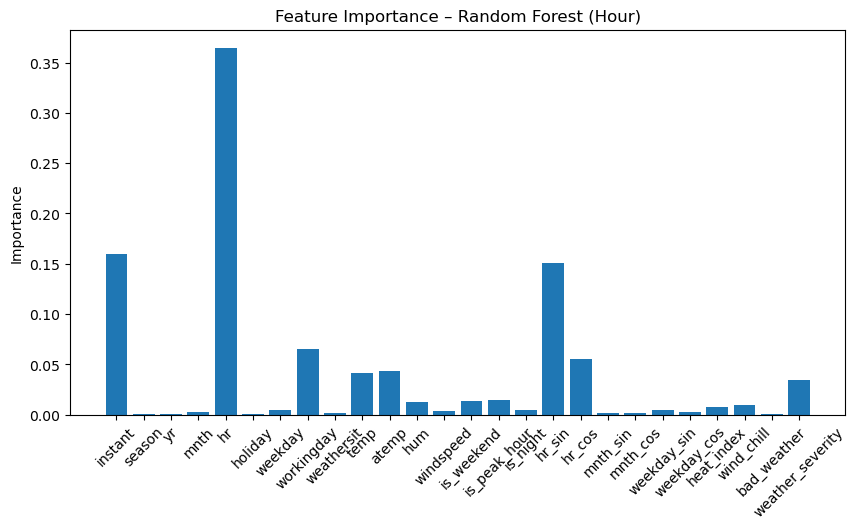

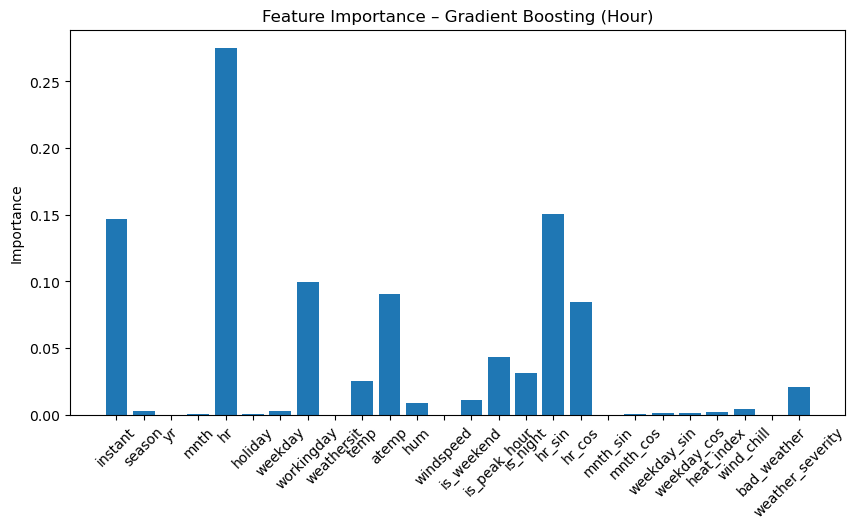

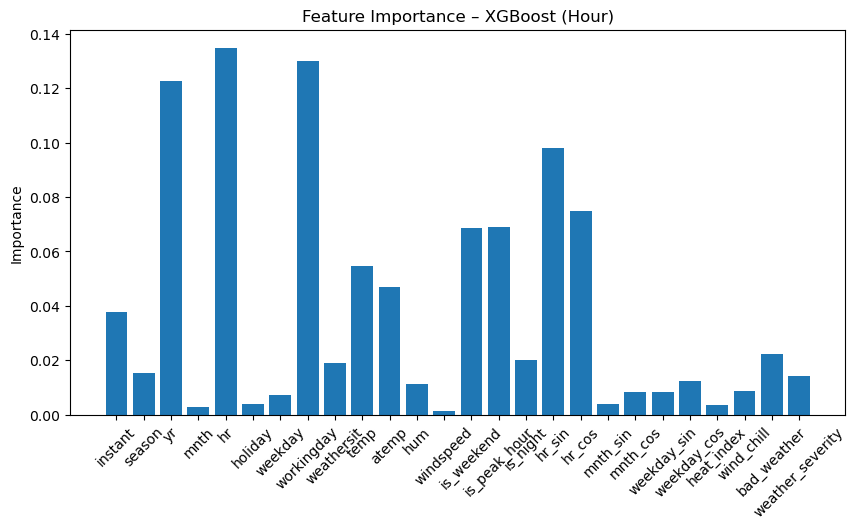

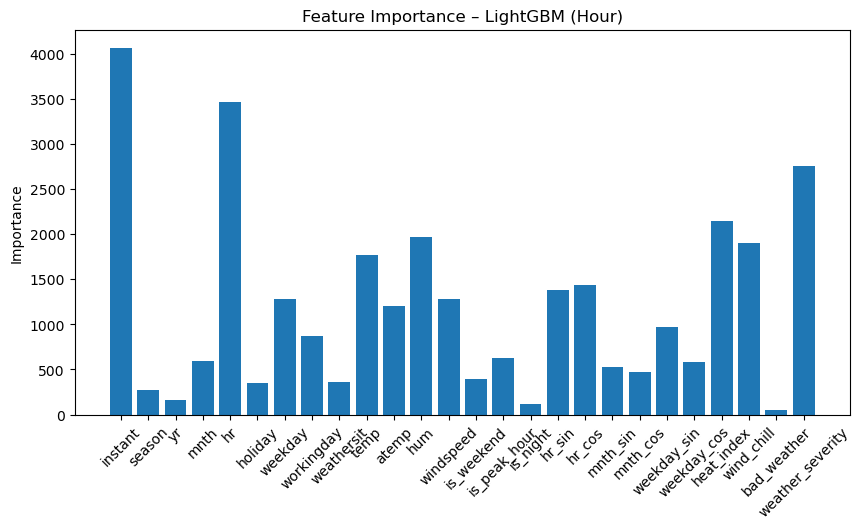

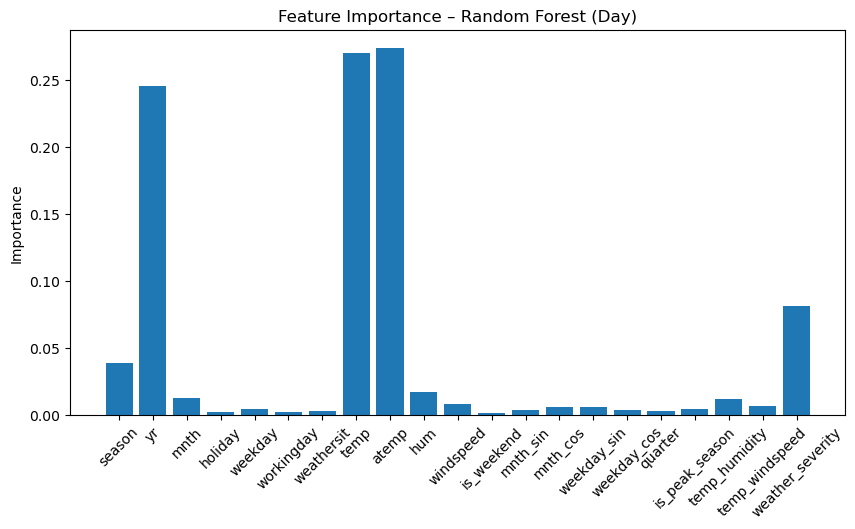

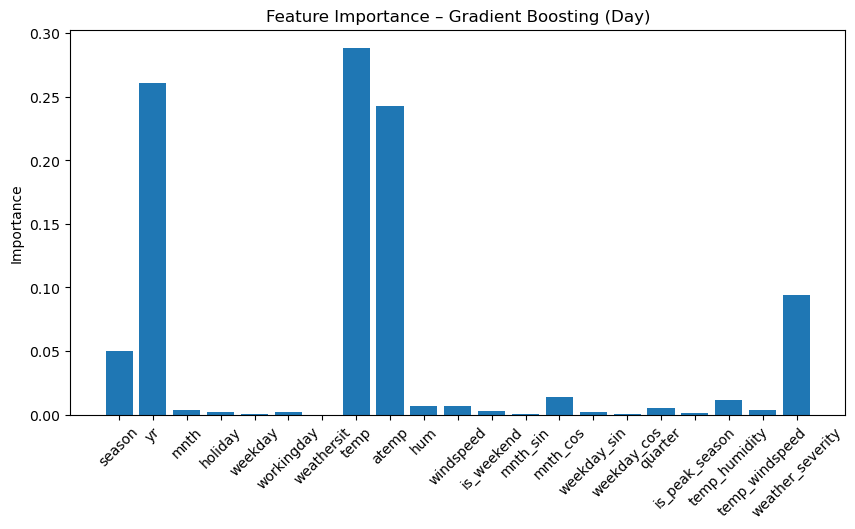

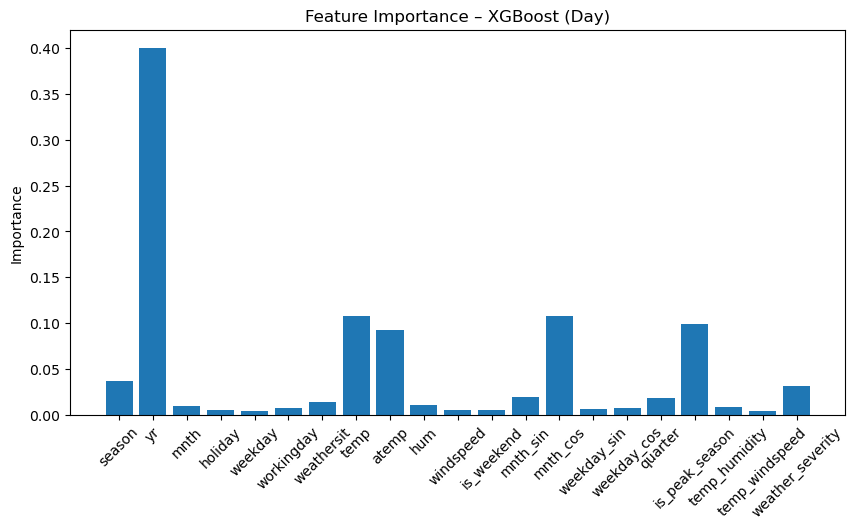

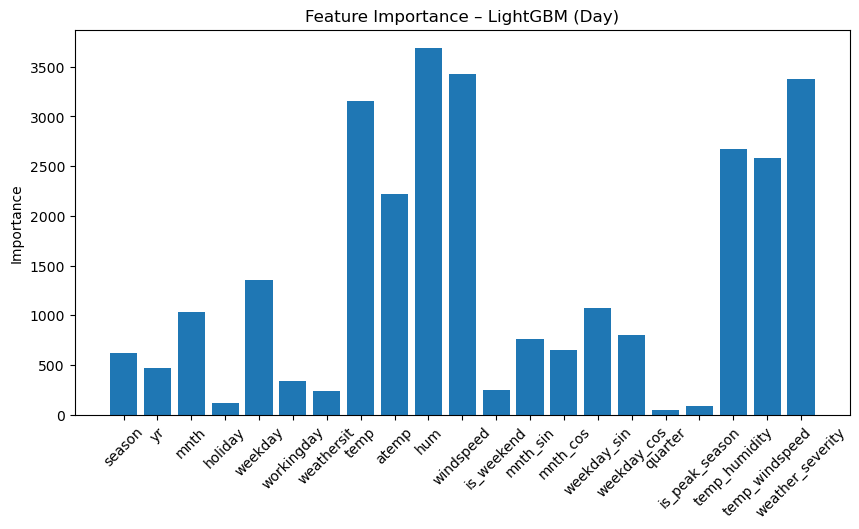

In [18]:
# Hour
for name, model in trained_hour_models.items():
    if hasattr(model, "feature_importances_"):
        plt.figure(figsize=(10,5))
        plt.bar(X_train_hour.columns, model.feature_importances_)
        plt.xticks(rotation=45)
        plt.ylabel("Importance")
        plt.title(f"Feature Importance – {name} (Hour)")
        plt.show()

# Day
for name, model in trained_day_models.items():
    if hasattr(model, "feature_importances_"):
        plt.figure(figsize=(10,5))
        plt.bar(X_train_day.columns, model.feature_importances_)
        plt.xticks(rotation=45)
        plt.ylabel("Importance")
        plt.title(f"Feature Importance – {name} (Day)")
        plt.show()


In [19]:
for name, model in trained_hour_models.items():
    if hasattr(model, "feature_importances_"):
        imp_df = pd.DataFrame({"Feature": X_train_hour.columns, "Importance": model.feature_importances_})
        print(f"\nTop 5 Features – {name} (Hour)")
        print(imp_df.sort_values(by="Importance", ascending=False).head())

for name, model in trained_day_models.items():
    if hasattr(model, "feature_importances_"):
        imp_df = pd.DataFrame({"Feature": X_train_day.columns, "Importance": model.feature_importances_})
        print(f"\nTop 5 Features – {name} (Day)")
        print(imp_df.sort_values(by="Importance", ascending=False).head())



Top 5 Features – Random Forest (Hour)
       Feature  Importance
4           hr    0.364650
0      instant    0.159734
16      hr_sin    0.150284
7   workingday    0.064957
17      hr_cos    0.054813

Top 5 Features – Gradient Boosting (Hour)
       Feature  Importance
4           hr    0.275155
16      hr_sin    0.150798
0      instant    0.146521
7   workingday    0.099351
10       atemp    0.090176

Top 5 Features – XGBoost (Hour)
       Feature  Importance
4           hr    0.134772
7   workingday    0.130109
2           yr    0.122648
16      hr_sin    0.098122
17      hr_cos    0.074849

Top 5 Features – LightGBM (Hour)
             Feature  Importance
0            instant        4063
4                 hr        3464
25  weather_severity        2760
22        heat_index        2144
11               hum        1973

Top 5 Features – Random Forest (Day)
             Feature  Importance
8              atemp    0.273918
7               temp    0.269857
1                 yr    0.2453

In [20]:
print("=== Hour Dataset Model Metrics ===")
for i, row in hour_results.iterrows():
    print(f"Model: {row['Model']}")
    print(f"R² Score: {row['R2']:.4f}")
    print(f"RMSE: {row['RMSE']:.4f}")
    print(f"MAE: {row['MAE']:.4f}")
    print("-"*35)


=== Hour Dataset Model Metrics ===
Model: XGBoost
R² Score: 0.8936
RMSE: 71.9279
MAE: 44.7644
-----------------------------------
Model: LightGBM
R² Score: 0.8755
RMSE: 77.7903
MAE: 49.0309
-----------------------------------
Model: Random Forest
R² Score: 0.8690
RMSE: 79.8118
MAE: 48.3999
-----------------------------------
Model: Gradient Boosting
R² Score: 0.8156
RMSE: 94.6867
MAE: 64.6110
-----------------------------------


In [21]:
print("=== Day Dataset Model Metrics ===")
for i, row in day_results.iterrows():
    print(f"Model: {row['Model']}")
    print(f"R² Score: {row['R2']:.4f}")
    print(f"RMSE: {row['RMSE']:.4f}")
    print(f"MAE: {row['MAE']:.4f}")
    print("-"*35)


=== Day Dataset Model Metrics ===
Model: Gradient Boosting
R² Score: 0.6856
RMSE: 1051.1479
MAE: 881.4609
-----------------------------------
Model: XGBoost
R² Score: 0.6700
RMSE: 1076.8119
MAE: 875.1977
-----------------------------------
Model: LightGBM
R² Score: 0.6049
RMSE: 1178.3915
MAE: 989.9385
-----------------------------------
Model: Random Forest
R² Score: 0.5591
RMSE: 1244.6948
MAE: 1028.7718
-----------------------------------


In [22]:
print("=== Hour Dataset ===")
display(hour_results.style.format({
    "R2": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}"
}))

print("=== Day Dataset ===")
display(day_results.style.format({
    "R2": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}"
}))


=== Hour Dataset ===


,Model,R2,RMSE,MAE
2,XGBoost,0.8936,71.9279,44.7644
3,LightGBM,0.8755,77.7903,49.0309
0,Random Forest,0.8690,79.8118,48.3999
1,Gradient Boosting,0.8156,94.6867,64.6110


=== Day Dataset ===


,Model,R2,RMSE,MAE
1,Gradient Boosting,0.6856,1051.1479,881.4609
2,XGBoost,0.6700,1076.8119,875.1977
3,LightGBM,0.6049,1178.3915,989.9385
0,Random Forest,0.5591,1244.6948,1028.7718


In [23]:
# Sort by R² descending
hour_results_sorted = hour_results.sort_values("R2", ascending=False)

# Get best model
best_hour_model_name = hour_results_sorted.iloc[0]["Model"]
best_hour_r2 = hour_results_sorted.iloc[0]["R2"]

print(f"Best Hour Model: {best_hour_model_name}")
print(f"R² Score: {best_hour_r2:.4f}")


Best Hour Model: XGBoost
R² Score: 0.8936


In [24]:
day_results_sorted = day_results.sort_values("R2", ascending=False)

best_day_model_name = day_results_sorted.iloc[0]["Model"]
best_day_r2 = day_results_sorted.iloc[0]["R2"]

print(f"Best Day Model: {best_day_model_name}")
print(f"R² Score: {best_day_r2:.4f}")


Best Day Model: Gradient Boosting
R² Score: 0.6856


In [25]:
best_hour_model = trained_hour_models[best_hour_model_name]
best_day_model = trained_day_models[best_day_model_name]


In [26]:
import pickle
with open("best_hour_model.pkl", "wb") as f:
    pickle.dump(best_hour_model, f)

print("Best Hour model saved as best_hour_model.pkl")


Best Hour model saved as best_hour_model.pkl


In [27]:
with open("best_day_model.pkl", "wb") as f:
    pickle.dump(best_day_model, f)

print("Best Day model saved as best_day_model.pkl")


Best Day model saved as best_day_model.pkl


In [28]:
import pickle

# Load Hour Model
hour_model = pickle.load(open("best_hour_model.pkl", "rb"))

# Load Day Model
day_model = pickle.load(open("best_day_model.pkl", "rb"))

# Example prediction
y_pred = hour_model.predict(X_test_hour)
